<a href="https://colab.research.google.com/github/adityakommoju36/FAKE-PROFILE-DETECTION-USING-DEEP-LEARNING/blob/main/FAKE_PROFILE_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv('twibot-20.csv')
df.head()

,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type
0,0,15-10-2016 21:32,False,False,"Blame @xaiax, Inspired by @MakingInvisible, us...",4,1589,4,False,7.870000e+17,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/7874121826...,best_in_dumbest,11041,False,7.870,1403,1
1,1,09-11-2016 05:01,False,False,Photographing the American West since 1980. I ...,536,860,880,False,7.960000e+17,en,Estados Unidos,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/8023296328...,CJRubinPhoto,252,False,0.183,1379,0
2,2,17-06-2017 05:34,False,False,Scruffy looking nerf herder and @twitch broadc...,3307,172,594,True,8.760000e+17,en,"Los Angeles, CA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1278890453...,SVGEGENT,1001,False,0.864,1159,0
3,3,21-07-2016 13:32,True,False,Wife.Godmother.Friend.Feline Fanatic! Assistan...,8433,517,633,True,7.560000e+17,en,"Birmingham, AL",NaN,http://pbs.twimg.com/profile_images/1284884924...,TinkerVHELPK5,1324,False,0.889,1489,0
4,4,15-01-2012 16:32,False,False,Loan coach at @mancity & Aspiring DJ,88,753678,116,True,4.647813e+08,en,"England, United Kingdom",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9952566258...,JoleonLescott,4202,True,1.339,3138,0


In [ ]:

pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:

# importing libraries
import pandas as pd
import scipy
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    37438 non-null  int64  
 1   created_at                    37438 non-null  object 
 2   default_profile               37438 non-null  bool   
 3   default_profile_image         37438 non-null  bool   
 4   description                   30181 non-null  object 
 5   favourites_count              37438 non-null  int64  
 6   followers_count               37438 non-null  int64  
 7   friends_count                 37438 non-null  int64  
 8   geo_enabled                   37438 non-null  bool   
 9   id                            37438 non-null  float64
 10  lang                          29481 non-null  object 
 11  location                      37434 non-null  object 
 12  profile_background_image_url  32939 non-null  object 
 13  p

In [ ]:
df.fillna(0,inplace=True)

In [ ]:
df.isnull().sum()


,0
Unnamed: 0,0
created_at,0
default_profile,0
default_profile_image,0
description,0
favourites_count,0
followers_count,0
friends_count,0
geo_enabled,0
id,0


In [ ]:
df.describe()


,Unnamed: 0,favourites_count,followers_count,friends_count,id,statuses_count,average_tweets_per_day,account_age_days,account_type
count,37438.000000,37438.000000,3.743800e+04,3.743800e+04,3.743800e+04,3.743800e+04,37438.000000,37438.000000,37438.000000
mean,18718.500000,12302.062183,3.703098e+05,4.445925e+03,1.221485e+17,2.107339e+04,6.891668,3022.128052,0.532080
std,10807.564026,33923.650237,2.470829e+06,4.954520e+04,3.004180e+17,6.732977e+04,24.580116,1013.695870,0.498976
min,0.000000,0.000000,0.000000e+00,0.000000e+00,4.180000e+02,0.000000e+00,0.000000,483.000000,0.000000
25%,9359.250000,362.000000,3.500000e+01,3.700000e+01,9.957306e+07,1.336250e+03,0.495000,2316.250000,0.000000
50%,18718.500000,2066.000000,3.650000e+02,2.960000e+02,3.991474e+08,4.209000e+03,1.488000,3219.000000,1.000000
75%,28077.750000,8879.000000,8.440250e+03,8.930000e+02,2.453826e+09,1.715375e+04,5.528000,3888.000000,1.000000
max,37437.000000,885123.000000,1.216415e+08,4.343060e+06,1.120000e+18,2.771910e+06,1269.055000,5158.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    37438 non-null  int64  
 1   created_at                    37438 non-null  object 
 2   default_profile               37438 non-null  bool   
 3   default_profile_image         37438 non-null  bool   
 4   description                   37438 non-null  object 
 5   favourites_count              37438 non-null  int64  
 6   followers_count               37438 non-null  int64  
 7   friends_count                 37438 non-null  int64  
 8   geo_enabled                   37438 non-null  bool   
 9   id                            37438 non-null  float64
 10  lang                          37438 non-null  object 
 11  location                      37438 non-null  object 
 12  profile_background_image_url  37438 non-null  object 
 13  p

In [ ]:
df.description

,description
0,"Blame @xaiax, Inspired by @MakingInvisible, us..."
1,Photographing the American West since 1980. I ...
2,Scruffy looking nerf herder and @twitch broadc...
3,Wife.Godmother.Friend.Feline Fanatic! Assistan...
4,Loan coach at @mancity & Aspiring DJ
...,...
37433,"Role: Stock Taker. Past Roles: Nanny, Sales As..."
37434,KINGDOM LANDLORD #FreeCornBread
37435,Bienvenid@s al Twitter Oficial de Sergio Dalma...
37436,Just a good guy wrapped up in a bad system.\nA...


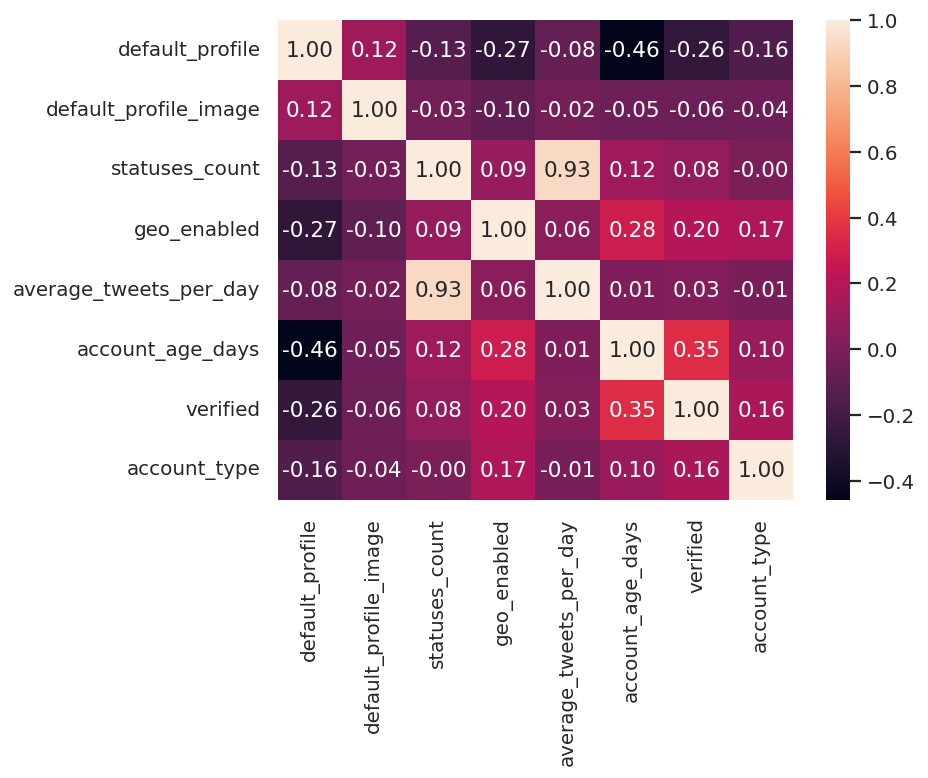

In [ ]:
#correlation
sns.set(style="white")
data = df.loc[:,['default_profile','default_profile_image','statuses_count','geo_enabled','average_tweets_per_day','account_age_days','verified','account_type']]

corr =data.corr()

plt.figure(dpi=130)
sns.heatmap(data.corr(), annot=True, fmt= '.2f')
plt.show()


In [ ]:
corr['account_type'].sort_values(ascending = False)


,account_type
account_type,1.000000
geo_enabled,0.174080
verified,0.158658
account_age_days,0.101089
statuses_count,-0.001109
average_tweets_per_day,-0.009102
default_profile_image,-0.043251
default_profile,-0.156004


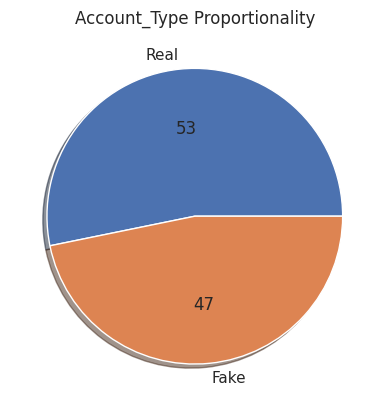

In [ ]:
plt.pie(df.account_type.value_counts(),
        labels= ['Real', 'Fake'],
        autopct='%.f', shadow=True)
plt.title('Account_Type Proportionality')
plt.show()


In [ ]:
# separate array into input and output components

X = data.drop(columns =['account_type'])
Y = df.account_type


In [ ]:
# initialising the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# learning the statistical parameters for each of the data and transforming
rescaledX = scaler.fit_transform(data)
rescaledX[:5]


array([[0.00000000e+00, 0.00000000e+00, 3.98317406e-03, 0.00000000e+00,
        6.20146487e-03, 1.96791444e-01, 0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 9.09120426e-05, 0.00000000e+00,
        1.44201788e-04, 1.91657754e-01, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 3.61122836e-04, 1.00000000e+00,
        6.80821556e-04, 1.44598930e-01, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 4.77648986e-04, 1.00000000e+00,
        7.00521254e-04, 2.15187166e-01, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.51592223e-03, 1.00000000e+00,
        1.05511581e-03, 5.67914439e-01, 1.00000000e+00, 0.00000000e+00]])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
rescaledX = scaler.transform(X)
rescaledX[:5]


array([[-0.85077821, -0.12300468, -0.14900572, -0.9158118 ,  0.03980231,
        -1.59727362, -0.50264466],
       [-0.85077821, -0.12300468, -0.30924901, -0.9158118 , -0.27293432,
        -1.62094968, -0.50264466],
       [-0.85077821, -0.12300468, -0.29812451,  1.0919274 , -0.24522863,
        -1.8379802 , -0.50264466],
       [ 1.17539447, -0.12300468, -0.29332716,  1.0919274 , -0.24421154,
        -1.51243442, -0.50264466],
       [-0.85077821, -0.12300468, -0.25058176,  1.0919274 , -0.22590381,
         0.11430795,  1.98947702]])

In [ ]:
pip install --upgrade torch torchvision torchaudio transformers

In [ ]:
import torch

# Safe import to avoid circular import issues
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"

from transformers import BertTokenizer, BertModel


RuntimeError: Failed to import transformers.models.bert.modeling_bert because of the following error (look up to see its traceback):
Detected that PyTorch and torchvision were compiled with different CUDA major versions. PyTorch has CUDA Version=11.8 and torchvision has CUDA Version=12.4. Please reinstall the torchvision that matches your PyTorch install.

In [ ]:
import pandas as pd
import torch
from transformers import BertTokenizerFast, BertModel
import numpy as np
from tqdm import tqdm

# ✅ Check GPU Availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ✅ Load dataset
file_path = "twibot-20.csv"
df = pd.read_csv(file_path, dtype={'id': str})  # Ensure 'id' is string

# ✅ Use a Smaller Model (Optional)
MODEL_NAME = "distilbert-base-uncased"  # Faster than "bert-base-uncased"

# ✅ Load Tokenizer & Model
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
bert_model = BertModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

# ✅ Select text column for BERT embeddings
text_column = "description" if "description" in df.columns else "tweets"
df[text_column] = df[text_column].fillna("")

# ✅ Optimize Tokenization (Do it once, not in a loop)
all_texts = df[text_column].tolist()
tokenized_data = tokenizer(all_texts, padding=True, truncation=True, return_tensors="pt", max_length=256)

# ✅ Extract BERT Features (Use Batching)
batch_size = 64  # Increase if GPU has enough memory
bert_features = []

with torch.no_grad():
    for i in tqdm(range(0, len(all_texts), batch_size)):
        batch_inputs = {key: val[i:i + batch_size].to(device) for key, val in tokenized_data.items()}
        outputs = bert_model(**batch_inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # Extract CLS token
        bert_features.append(cls_embeddings)

# ✅ Convert to NumPy Array
bert_features = np.vstack(bert_features)  # Stack all batches

# ✅ Convert to DataFrame
feature_columns = [f"bert_feat_{i}" for i in range(bert_features.shape[1])]
bert_df = pd.DataFrame(bert_features, columns=feature_columns)
bert_df.insert(0, "id", df["id"])  # Add ID column
bert_df.insert(1, "account_type", df["account_type"])  # Add account_type column

# ✅ Save to CSV
bert_df.to_csv("bert_features.csv", index=False)
print("✅ BERT features saved to bert_features.csv")


RuntimeError: Failed to import transformers.models.bert.modeling_bert because of the following error (look up to see its traceback):
Detected that PyTorch and torchvision were compiled with different CUDA major versions. PyTorch has CUDA Version=11.8 and torchvision has CUDA Version=12.4. Please reinstall the torchvision that matches your PyTorch install.

In [ ]:
pip install torch-geometric

In [ ]:
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
import networkx as nx

# ✅ Load dataset
file_path = "twibot-20.csv"
df = pd.read_csv(file_path)

# ✅ Ensure ID column is string type
df['id'] = df['id'].astype(str)

# ✅ Create graph from ID relationships (fallback if no 'source', 'target' columns)
if 'source' in df.columns and 'target' in df.columns:
    edges = list(zip(df['source'].astype(str), df['target'].astype(str)))
else:
    edges = [(str(row['id']), str(row['id'])) for _, row in df.iterrows()]  # Self-loops for isolated nodes

# ✅ Build NetworkX Graph
G = nx.Graph()
G.add_edges_from(edges)

# ✅ Get node labels (account type mapping)
account_type_map = {str(row['id']): int(row['account_type']) for _, row in df.iterrows()}

# ✅ Assign Labels to Nodes
node_labels = []
node_list = list(G.nodes())

for node in node_list:
    node_labels.append(account_type_map.get(node, -1))  # Use -1 for unknown nodes

# ✅ Convert Graph to PyTorch Geometric Format
node_mapping = {node: i for i, node in enumerate(node_list)}  # Mapping: Node ID → Index
edge_index = torch.tensor([[node_mapping[src], node_mapping[tgt]] for src, tgt in G.edges()], dtype=torch.long).t().contiguous()

# ✅ Initialize Node Features (One-hot encoding for account type)
num_nodes = len(node_list)
node_features = torch.zeros((num_nodes, 2))  # 2 Features: (0 = human, 1 = bot)

for i, label in enumerate(node_labels):
    if label in [0, 1]:  # Assign one-hot encoding
        node_features[i][label] = 1
    else:
        node_features[i] = torch.tensor([0.5, 0.5])  # Unknown nodes get equal probability

# ✅ Create PyTorch Geometric Data Object
data = Data(x=node_features, edge_index=edge_index)

print(f"✅ Graph created with {data.x.shape[0]} nodes and {data.edge_index.shape[1]} edges.")
print("✅ Node features successfully assigned!")

# ✅ Define GraphSAGE Model (Spatial-based GCN)
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# ✅ Initialize Model
model = GraphSAGE(in_channels=2, hidden_channels=16, out_channels=16)
model.eval()  # Set to evaluation mode

# ✅ Extract GCN Features
with torch.no_grad():
    gcn_features = model(data).cpu().numpy()

# ✅ Convert to DataFrame
gcn_df = pd.DataFrame(gcn_features)
gcn_df.insert(0, "id", node_list)  # Add ID column
gcn_df.insert(1, "account_type", node_labels)  # Add account_type column

# ✅ Save GCN Features
gcn_df.to_csv("gcn_features.csv", index=False)
print("✅ GCN features with ID and account_type saved to gcn_features.csv")


In [ ]:
import pandas as pd

# ✅ Load extracted features
bert_df = pd.read_csv("bert_features.csv")  # BERT Features (text)
gcn_df = pd.read_csv("gcn_features.csv")  # GCN Features (graph)

# ✅ Merge on 'id' column
fused_df = pd.merge(bert_df, gcn_df, on="id", how="inner")  # Inner join ensures common IDs

# ✅ Save Fused Features
fused_df.to_csv("fused_features.csv", index=False)
print("✅ Fused BERT + GCN features saved to fused_features.csv")


In [ ]:
pip install nltk

In [ ]:
import pandas as pd

df = pd.read_csv("fused_features.csv")
print("🔍 Available columns in fused_features.csv:", df.columns.tolist())

In [ ]:
df.rename(columns={"account_type_x": "account_type"}, inplace=True)

In [ ]:
print(df["account_type"].isna().sum())  # Count NaN values
print(df["account_type"].unique())  # Check unique values


In [ ]:
print(df["account_type"].value_counts(dropna=False))  # Check counts
print(df["account_type"].apply(type).value_counts())  # Check data types


In [ ]:
df["account_type"] = df["account_type"].astype(str).str.strip().map({"0": 0, "1": 1}).astype(int)

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# ✅ Check available columns
print("🔍 Available columns:", df.columns)



# ✅ Ensure 'account_type' column exists
if "account_type" not in df.columns:
    raise ValueError("❌ 'account_type' column is missing in fused_features.csv!")

# ✅ Convert account_type to numeric (if it's categorical)
df["account_type"] = df["account_type"].astype(str).str.strip().map({"0": 0, "1": 1}).astype(int)


# ✅ Split features and labels
X = df.drop(columns=["id", "account_type"], errors="ignore").values  # Drop 'id' & keep features
y = df["account_type"].values  # Target labels (0 = human, 1 = bot)

# ✅ Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Convert to Torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# ✅ Define DNN Model
class DNN(nn.Module):
    def __init__(self, input_dim):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)  # Output layer for binary classification
        self.sigmoid = nn.Sigmoid()  # Activation for binary output

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# ✅ Initialize model
input_dim = X_train.shape[1]
model = DNN(input_dim)

# ✅ Loss & Optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ✅ Training loop
num_epochs = 50
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor).squeeze()
    loss = criterion(outputs, y_train_tensor.float())  # Ensure labels are float for BCELoss
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# ✅ Evaluate Model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).squeeze()
    y_pred = (y_pred > 0.5).float()
    accuracy = (y_pred == y_test_tensor.float()).sum().item() / y_test_tensor.size(0)

print(f"✅ Model Accuracy: {accuracy * 100:.2f}%")


In [ ]:
import torch

# ✅ Save model weights
torch.save(model.state_dict(), "dnn_model.pth")

# ✅ Save the scaler
import joblib
joblib.dump(scaler, "scaler.pkl")

# ✅ Download the files if using Google Colab
from google.colab import files
files.download("dnn_model.pth")
files.download("scaler.pkl")


In [ ]:
import numpy as np
import torch

# ✅ Ensure model is in evaluation mode
model.eval()


# ✅ Compute accuracy for fake (1) and real (0) profiles
fake_indices = (y_test_tensor.numpy() == 1)  # Indices of actual fake profiles
real_indices = (y_test_tensor.numpy() == 0)  # Indices of actual real profiles

fake_accuracy = np.mean(y_pred[fake_indices] == 1)  # Correctly classified fake profiles
real_accuracy = np.mean(y_pred[real_indices] == 0)  # Correctly classified real profiles

# ✅ Print results

print(f"🔹 **Fake Profile Accuracy:** {fake_accuracy * 100:.2f}%")
print(f"🔹 **Real Profile Accuracy:** {real_accuracy * 100:.2f}%")


In [ ]:

# ✅ Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# ✅ Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:

# ✅ Compute ROC Curve and AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# ✅ Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# ✅ Print Model Performance
print(f"✅ Model AUC Score: {roc_auc:.4f}")

In [ ]:
import pandas as pd

# Load the dataset (try different encodings if needed)
file_path = "twibot-20-updated.csv"

df = pd.read_csv(file_path, encoding="utf-8", on_bad_lines="skip")

# Define mapping from p_type to account_type
mapping = {
    "bot": "fake",
    "human": "real"
}

# Update account_type based on p_type
df["account_type"] = df["p_type"].map(mapping).fillna(df["account_type"])

# Save the updated file
df.to_csv("twibot-20-updated-new.csv", index=False)

print("Updated file saved as 'twibot-20-updated-new.csv'")
